# 8.1D Distinction Task – Sydney Housing Price Prediction and Decision Support System

**Ashriya Singla (225682089)** 

This notebook contains the code for Parts 1–4 of the mini project (data checks, exploration, feature engineering, modelling, error analysis) and trains and saves the model used by the web app in Part 5 (`app.py`).
Each code cell is preceded by an explanation of what it does and why, and followed by observations once you have run it.

**GenAI acknowledgement:** "Claude (Anthropic) was used to draft the code structure and explanatory text of this notebook. I collected the data myself, ran the code, checked the outputs and wrote/edited the interpretation.

## Part 1 – Data loading, cleaning and quality checks
**What the next cell does.** Imports the libraries, sets a random seed for reproducibility, and defines where the data lives.
`housing_features.py` (imported as `hf`) holds the feature-engineering code that is shared with the web app, so the app applies exactly the same transformations as the notebook.

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import (KFold, RepeatedKFold, cross_val_predict, cross_validate,
                                     learning_curve, validation_curve)
import housing_features as hf

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 40
DATA_CSV, DATA_XLSX = "sydney_housing_data.csv", "sydney_housing_data.xlsx"

**What the next cell does.** Loads the dataset you collected (CSV, or the Excel template's `Data` sheet) and applies light, documented cleaning:
column names are lower-cased; completely empty rows are removed; `sale_price` is converted from text such as `"$1,250,000"` to a number; dates are parsed (day-first, Australian format);
rows without a price are dropped (they cannot be used for supervised learning); and exact duplicate properties are removed.
Every cleaning step prints how many rows it affected so it can be reported.

In [2]:
if os.path.exists(DATA_CSV):
    raw = pd.read_csv(DATA_CSV)
elif os.path.exists(DATA_XLSX):
    raw = pd.read_excel(DATA_XLSX, sheet_name="Data")
else:
    raise FileNotFoundError("Put sydney_housing_data.csv (or .xlsx) in this folder - see README.md")

df = raw.copy()
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
n0 = len(df)
df = df.dropna(how="all")
print(f"Rows read: {n0} | after removing empty rows: {len(df)}")

df["sale_price"] = pd.to_numeric(df["sale_price"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
n1 = len(df); df = df.dropna(subset=["sale_price"]); print(f"Dropped {n1-len(df)} rows with no usable sale_price")

df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce", dayfirst=True)
print(f"Rows with unparseable/missing sale_date: {df['sale_date'].isna().sum()}")

dup_cols = [c for c in ["address", "sale_date"] if c in df.columns]
if dup_cols:
    n2 = len(df); df = df.drop_duplicates(subset=dup_cols); print(f"Removed {n2-len(df)} duplicate properties")

for c in ["suburb", "property_type", "sale_method"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip().str.title().replace({"Nan": np.nan})
df = df.reset_index(drop=True)
df.head()

Rows read: 173 | after removing empty rows: 173
Dropped 53 rows with no usable sale_price
Rows with unparseable/missing sale_date: 1
Removed 0 duplicate properties


,address,suburb,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,building_size_sqm,year_built,distance_to_cbd_km,distance_to_station_km,sale_method,description,listing_url
0,2/48 Edward Street,Bondi,"830,000.00",2026-09-29,Unit,1.00,1.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,Art Deco one-bedroom apartment with high ceili...,https://www.realestate.com.au/sold/property-ap...
1,2/30-34 Penkivil Street,Bondi,"2,150,000.00",2026-09-23,Unit,2.00,2.00,1.00,NaN,115.00,"2,005.00",NaN,NaN,Auction,Large ground-floor residence with an expansive...,https://www.realestate.com.au/sold/property-ap...
2,62 Watson Street,Bondi,"3,300,000.00",2026-09-22,House,3.00,2.00,1.00,265.00,212.00,"1,910.00",NaN,NaN,Auction,Three-bedroom semi on a deep block with modern...,https://www.realestate.com.au/sold/property-ho...
3,2/26 Fletcher Street,Bondi,"1,581,000.00",2026-09-17,Unit,2.00,1.00,0.00,NaN,96.00,NaN,NaN,NaN,Other,Oversized renovated Art Deco apartment with an...,https://www.realestate.com.au/sold/property-ap...
4,7/28-30 Fletcher Street,Bondi,"2,450,000.00",2026-09-15,Unit,2.00,1.00,1.00,NaN,108.00,"2,004.00",NaN,NaN,Private Treaty,Renovated dual-level apartment with townhouse-...,https://www.realestate.com.au/sold/property-ap...


**What the next cell does.** Checks the task requirements (at least 100 properties, at least 30 per suburb) and summarises data quality:
sample sizes, the share of missing values in each column, and simple plausibility checks (very low prices, zero bedrooms, very large land sizes).
These results feed the "dataset quality, bias and limitations" discussion in the report.

In [3]:
counts = df["suburb"].value_counts()
print("Properties per suburb:\n", counts.to_string(), f"\nTotal: {len(df)}")
print("REQUIREMENT MET" if (len(df) >= 100 and counts.min() >= 30 and len(counts) == 3)
      else "WARNING: need >=100 properties in total, >=30 in each of exactly 3 suburbs")

missing = (df.isna().mean() * 100).round(1).rename("% missing").to_frame()
display(missing.T)

checks = {
    "price < $200,000": int((df.sale_price < 200_000).sum()),
    "price > $10,000,000": int((df.sale_price > 10_000_000).sum()),
    "bedrooms == 0": int((df.get("bedrooms", pd.Series(dtype=float)) == 0).sum()),
    "land size > 5,000 sqm": int((df.get("land_size_sqm", pd.Series(dtype=float)) > 5000).sum()),
}
print("\nPlausibility checks (count of flagged rows):", checks)
df.describe(include="all").T

Properties per suburb:
 suburb
Blacktown     45
Bondi         42
Parramatta    33 
Total: 120
REQUIREMENT MET


,address,suburb,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,building_size_sqm,year_built,distance_to_cbd_km,distance_to_station_km,sale_method,description,listing_url
% missing,0.00,0.00,0.00,0.80,0.00,0.00,0.00,0.00,71.70,75.00,94.20,100.00,100.00,95.80,9.20,0.00



Plausibility checks (count of flagged rows): {'price < $200,000': 0, 'price > $10,000,000': 0, 'bedrooms == 0': 3, 'land size > 5,000 sqm': 0}


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
address,120,120,2/48 Edward Street,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb,120,3,Blacktown,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale_price,120.00,NaN,NaN,NaN,"1,251,676.67","320,000.00","598,750.00","787,500.00","1,520,000.00","5,416,000.00","1,035,029.31"
sale_date,119,NaN,NaN,NaN,2026-08-13 23:11:35.798319360,2026-04-21 00:00:00,2026-08-09 00:00:00,2026-09-04 00:00:00,2026-09-16 00:00:00,2026-09-30 00:00:00,NaN
property_type,120,4,Unit,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,120.00,NaN,NaN,NaN,2.47,0.00,2.00,2.00,3.00,7.00,1.14
bathrooms,120.00,NaN,NaN,NaN,1.62,1.00,1.00,2.00,2.00,4.00,0.70
car_spaces,120.00,NaN,NaN,NaN,1.28,0.00,1.00,1.00,1.00,6.00,1.08
land_size_sqm,34.00,NaN,NaN,NaN,417.49,63.00,230.25,467.00,574.05,739.80,218.86
building_size_sqm,30.00,NaN,NaN,NaN,119.69,68.70,97.25,114.00,127.50,217.00,37.35


In [4]:
# How much do suburb and property type overlap? (counts, row %, and Cramer's V)
from scipy.stats import chi2_contingency
ct = pd.crosstab(df["suburb"], df["property_type"])
display(ct)
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(0))
chi2 = chi2_contingency(ct)[0]
cramers_v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
print(f"Cramer's V between suburb and property type: {cramers_v:.2f}  (0 = no overlap, 1 = identical)")

# Columns with lots of missing values (rows with a usable price)
miss = (df.isna().mean() * 100).round(0).sort_values(ascending=False)
print("\nShare of missing values (%):"); print(miss[miss > 0].to_string())
print(f"\nSale dates: {df.sale_date.min().date()} to {df.sale_date.max().date()}; {(df.sale_date.dt.month == 9).mean() * 100:.0f}% of rows are from September")

property_type,House,Other,Townhouse,Unit
suburb,,,,
Blacktown,20,0,9,16
Bondi,10,1,0,31
Parramatta,0,0,1,32


property_type,House,Other,Townhouse,Unit
suburb,,,,
Blacktown,44.00,0.00,20.00,36.00
Bondi,24.00,2.00,0.00,74.00
Parramatta,0.00,0.00,3.00,97.00


Cramer's V between suburb and property type: 0.41  (0 = no overlap, 1 = identical)

Share of missing values (%):
distance_to_cbd_km       100.00
distance_to_station_km   100.00
sale_method               96.00
year_built                94.00
building_size_sqm         75.00
land_size_sqm             72.00
description                9.00
sale_date                  1.00

Sale dates: 2026-04-21 to 2026-09-30; 57% of rows are from September


### Dataset limitations
*(Figures are from this dataset: 120 sold properties with a usable price.)*

- **Parramatta has many apartments.** 32 of its 33 priced sales are units (97%) and the other is a townhouse; there is no house in the sample. Conclusions about Parramatta are really conclusions about apartments, and the model has never seen a Parramatta house.
- **Blacktown has many houses.** 20 of its 45 sales are houses (44%), plus 9 townhouses and 16 units. Bondi is mostly units (31 of 42, 74%) with 10 houses.
- **Suburb and property type overlap.** Each suburb has a different property mix (Cramér's V = 0.41, a moderate association), so the model cannot cleanly separate the "suburb effect" from the "property-type effect". Predicting a combination not seen in the data (e.g. a house in Parramatta) would be an extrapolation.
- **Some fields have many missing values.** Land size is blank for 72% of rows (structurally missing for strata units), building size 75%, year built 94%, sale method 96%, and the two distance columns were not collected (100%). These fields are dropped or weakly used, so the model relies mainly on bedrooms, bathrooms, car spaces, suburb, property type and (for houses) land size.
- **No independent external test set.** All results come from cross-validation on the same 120 properties, collected from one website in one period (April–September 2026, with 57% of sales in September). The feature set was also chosen using these same data, so reported errors are probably somewhat optimistic and may not hold for other suburbs, periods or sellers.
- **Selection bias from withheld prices.** 53 of the 173 collected sales (31%) had no public price and were excluded, so the model only learns from sales whose price was disclosed.
- **Small sample.** With 33–45 sales per suburb, a few unusual properties can change results noticeably.

## Part 2 – Data understanding
### 2.1 Distribution of prices and differences between suburbs
**What the next cell does.** Summarises sale prices for each suburb (count, mean, median, spread) and plots the overall distribution on a normal and a log scale.
House prices are usually *right-skewed* (a few very expensive sales stretch the tail), so a log transform often makes the distribution more symmetric, which suits many models.

,count,mean,median,std,min,max,q25,q75
suburb,,,,,,,,
Blacktown,45,"840,838.00","765,000.00","396,058.00","415,000.00","1,980,000.00","460,000.00","1,070,000.00"
Bondi,42,"2,204,940.00","1,960,000.00","1,214,445.00","595,000.00","5,416,000.00","1,446,250.00","2,712,500.00"
Parramatta,33,"598,667.00","605,000.00","93,170.00","320,000.00","785,000.00","555,000.00","660,000.00"


Skewness of price: 2.00 | skewness of log(price): 0.70


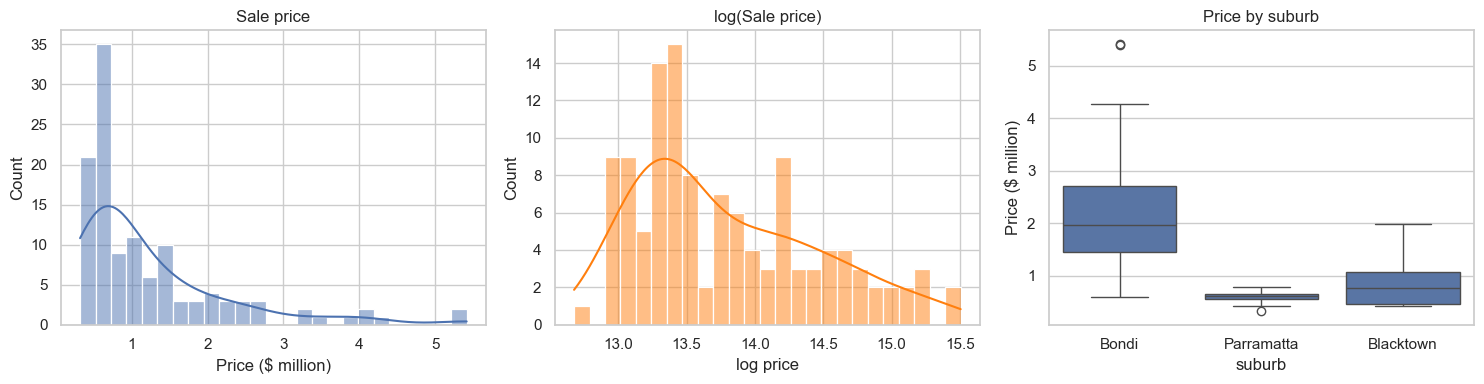

In [5]:
summary = df.groupby("suburb")["sale_price"].agg(
    count="count", mean="mean", median="median", std="std", min="min", max="max",
    q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75))
display(summary.round(0))
print("Skewness of price: %.2f | skewness of log(price): %.2f" % (df.sale_price.skew(), np.log(df.sale_price).skew()))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df.sale_price/1e6, bins=25, kde=True, ax=ax[0]); ax[0].set(title="Sale price", xlabel="Price ($ million)")
sns.histplot(np.log(df.sale_price), bins=25, kde=True, ax=ax[1], color="tab:orange"); ax[1].set(title="log(Sale price)", xlabel="log price")
sns.boxplot(data=df, x="suburb", y=df.sale_price/1e6, ax=ax[2]); ax[2].set(title="Price by suburb", ylabel="Price ($ million)")
plt.tight_layout(); plt.show()

**What the next cell does.** Looks at price by property type within each suburb and at the relationship between price and the main size variables (land size and bedrooms).
This shows whether the suburbs really are different markets and which variables appear to move with price.

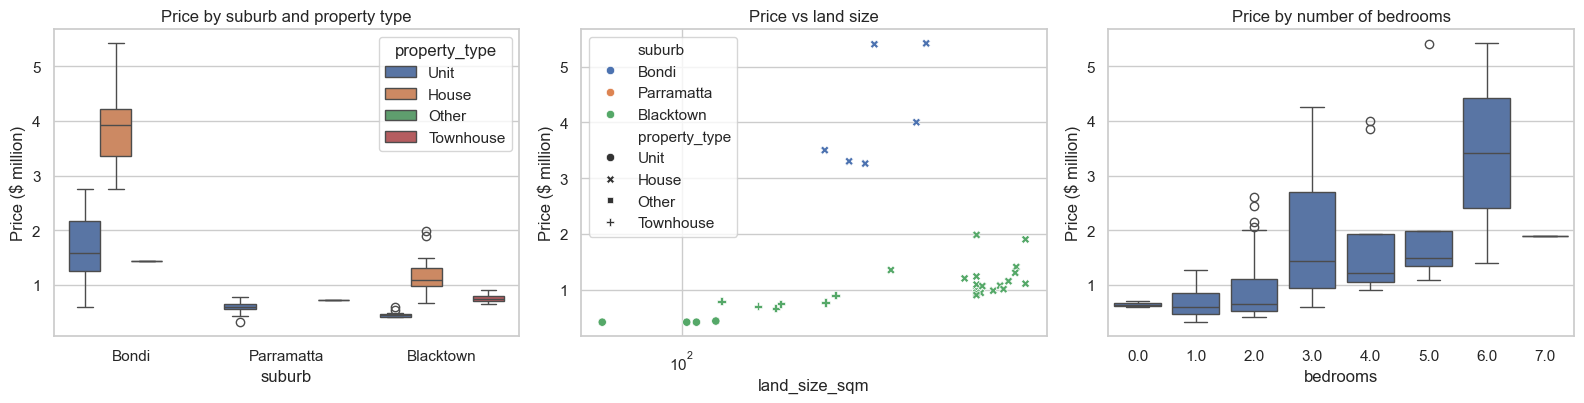

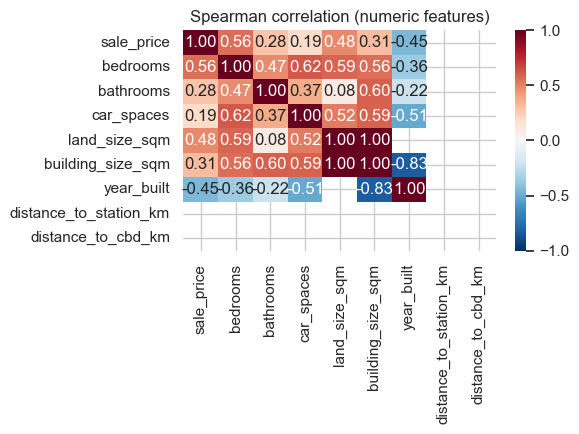

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
if "property_type" in df:
    sns.boxplot(data=df, x="suburb", y=df.sale_price/1e6, hue="property_type", ax=ax[0]); ax[0].set(title="Price by suburb and property type", ylabel="Price ($ million)")
if "land_size_sqm" in df:
    sns.scatterplot(data=df, x="land_size_sqm", y=df.sale_price/1e6, hue="suburb", style=df.get("property_type"), ax=ax[1]); ax[1].set(title="Price vs land size", ylabel="Price ($ million)"); ax[1].set_xscale("log")
if "bedrooms" in df:
    sns.boxplot(data=df, x="bedrooms", y=df.sale_price/1e6, ax=ax[2]); ax[2].set(title="Price by number of bedrooms", ylabel="Price ($ million)")
plt.tight_layout(); plt.show()

num_cols = [c for c in ["sale_price","bedrooms","bathrooms","car_spaces","land_size_sqm","building_size_sqm","year_built","distance_to_station_km","distance_to_cbd_km"] if c in df]
plt.figure(figsize=(6, 4.5)); sns.heatmap(df[num_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation (numeric features)"); plt.tight_layout(); plt.show()

### 2.2 Trends over time and unusual observations
**What the next cell does.** Plots each sale's price against its sale date (with a rolling median per suburb) to check for a market trend over the collection window.
A trend matters because a model that ignores time will confuse "cheap because it sold earlier" with "cheap because of its features".

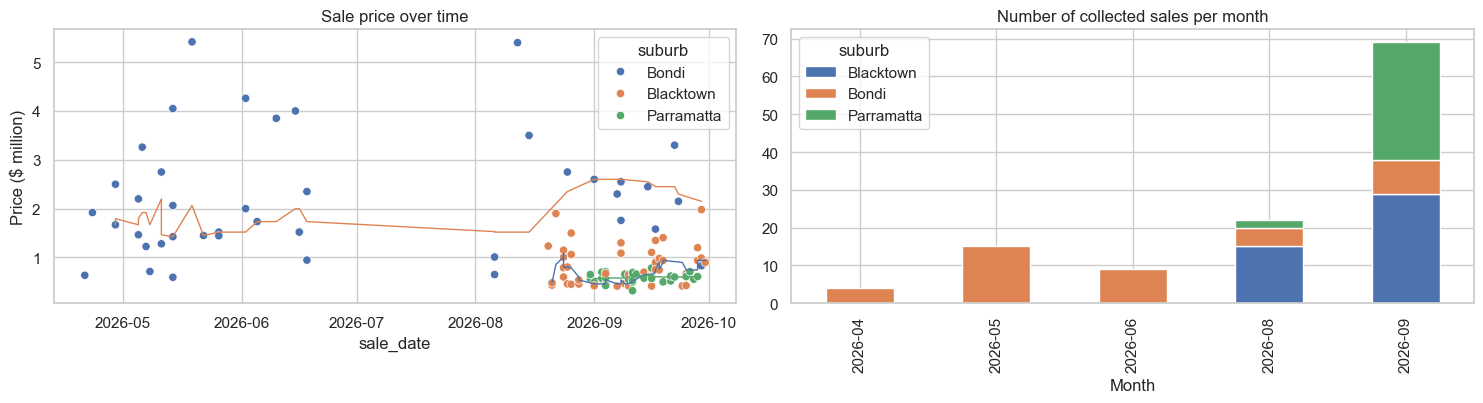

Sale dates range from 2026-04-21 to 2026-09-30


In [7]:
if df.sale_date.notna().sum() > 10:
    d = df.dropna(subset=["sale_date"]).sort_values("sale_date")
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
    sns.scatterplot(data=d, x="sale_date", y=d.sale_price/1e6, hue="suburb", ax=ax[0]); ax[0].set(title="Sale price over time", ylabel="Price ($ million)")
    for s, g in d.groupby("suburb"):
        ax[0].plot(g.sale_date, (g.sale_price/1e6).rolling(7, min_periods=3).median(), lw=1)
    monthly = d.groupby([d.sale_date.dt.to_period("M"), "suburb"]).size().unstack(fill_value=0)
    monthly.plot(kind="bar", stacked=True, ax=ax[1]); ax[1].set(title="Number of collected sales per month", xlabel="Month")
    plt.tight_layout(); plt.show()
    print("Sale dates range from", d.sale_date.min().date(), "to", d.sale_date.max().date())
else:
    print("Not enough valid sale dates to analyse trends")

**What the next cell does.** Flags potential outliers using the interquartile-range (IQR) rule *within each suburb* on log price (a sale that is unusual for its own suburb, not just expensive overall).
Points outside 1.5 x IQR are listed. They are **flagged, not deleted**: an unusually high price may be a genuine luxury home, and removing it would hide exactly the cases a valuation model needs to handle.

In [8]:
df["log_price"] = np.log(df.sale_price)
def iqr_flag(g):
    q1, q3 = g.quantile([.25, .75]); i = q3 - q1
    return (g < q1 - 1.5*i) | (g > q3 + 1.5*i)
df["price_outlier"] = df.groupby("suburb")["log_price"].transform(iqr_flag)
show = [c for c in ["address","suburb","property_type","bedrooms","land_size_sqm","sale_date","sale_price"] if c in df]
print(f"{df.price_outlier.sum()} potential price outliers (IQR rule within suburb)")
display(df.loc[df.price_outlier, show].sort_values("sale_price"))

2 potential price outliers (IQR rule within suburb)


,address,suburb,property_type,bedrooms,land_size_sqm,sale_date,sale_price
64,1404/1-3 Valentine Avenue,Parramatta,Unit,1.00,NaN,2026-09-11,"320,000.00"
69,8/64-66 Great Western Highway,Parramatta,Unit,1.00,NaN,2026-09-04,"425,000.00"


### 2.3 My expectation before feature engineering
The task asks for the three variables I expect to influence price most, **written down before any engineered feature is created**, so that I can later check my intuition against the evidence.
Edit the text below to reflect your own reasoning (this is a draft to adapt, not an answer to copy).

> **Expected top three:**
> 1. **Suburb (location)** – I expect suburb to have the strongest influence because Bondi, Parramatta and Blacktown represent very different property markets. Their location, accessibility, demand and general price levels are substantially different.
> 2. **Land size / property type** – I expect houses, townhouses and units to have different price patterns. Land size should also be important, particularly for houses, because larger blocks generally provide more space and development potential.
> 3. **Number of bedrooms (or bathrooms)** – I expect properties with more bedrooms to generally have higher prices because bedrooms provide a simple indication of the property's size and capacity.

### 2.4 Feature engineering
**What the next cell does.** Applies `hf.add_features`, which creates:
- `months_since_start` – time trend;
- `log_land`, `log_building`, `land_missing` – log-scaled sizes (skewed) plus a flag when land size is unknown (typical for units);
- `total_rooms`, `property_age`;
- **text features** from the agent's description: keyword flags such as renovated, pool, views, development potential, granny flat, luxury and transport, plus description length.

`choose_feature_sets` keeps only columns that are at least 30% complete (missing values are filled with the median and, for land size, flagged with `land_missing`) and defines three nested feature sets (**A** raw only, **B** plus engineered numeric features, **C** plus text flags) so that Part 3 can test whether each step actually helps.

In [9]:
REF_DATE = df.sale_date.min()
fe = hf.add_features(df, REF_DATE)
FEATURE_SETS = hf.choose_feature_sets(df, REF_DATE)
for k, v in FEATURE_SETS.items(): print(k, "->", v)

flag_cols = [c for c in fe.columns if c.startswith("txt_") and c != "txt_word_count"]
print("\nShare of listings mentioning each text feature (by suburb):")
display((fe.groupby(df.suburb)[flag_cols].mean() * 100).round(0))
fe[["suburb", "months_since_start", "log_land", "total_rooms"] + flag_cols].head()

A_raw -> {'num': ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm'], 'flags': [], 'cat': ['suburb', 'property_type']}
B_+engineered -> {'num': ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'months_since_start', 'log_land', 'total_rooms'], 'flags': ['land_missing'], 'cat': ['suburb', 'property_type']}
C_+text_flags -> {'num': ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_sqm', 'months_since_start', 'log_land', 'total_rooms', 'txt_word_count'], 'flags': ['land_missing', 'txt_renovated', 'txt_pool', 'txt_views', 'txt_development', 'txt_granny', 'txt_luxury', 'txt_transport'], 'cat': ['suburb', 'property_type']}

Share of listings mentioning each text feature (by suburb):


,txt_renovated,txt_pool,txt_views,txt_development,txt_granny,txt_luxury,txt_transport
suburb,,,,,,,
Blacktown,13.00,0.00,9.00,9.00,4.00,0.00,7.00
Bondi,40.00,17.00,36.00,5.00,12.00,19.00,0.00
Parramatta,24.00,0.00,24.00,0.00,0.00,3.00,6.00


,suburb,months_since_start,log_land,total_rooms,txt_renovated,txt_pool,txt_views,txt_development,txt_granny,txt_luxury,txt_transport
0,Bondi,5.29,NaN,2.00,0,0,0,0,0,0,0
1,Bondi,5.09,NaN,4.00,1,0,0,0,0,1,0
2,Bondi,5.06,5.58,5.00,1,0,0,1,0,0,0
3,Bondi,4.89,NaN,3.00,1,0,1,0,0,0,0
4,Bondi,4.83,NaN,3.00,1,0,0,0,0,1,0


## Part 3 – Model development and evaluation
### 3.1 Model selection and prediction (written before training)
Three different modelling approaches are compared, plus a naive baseline:
| Model | Approach | Why it is a candidate | Main risk |
|---|---|---|---|
| **Ridge regression** | Regularised linear model | Simple, interpretable, stable with ~100 rows; coefficients show the price effect of each feature | Cannot capture non-linear effects or interactions (e.g. land matters more in one suburb) |
| **Random forest** | Bagged decision trees | Handles non-linearity, interactions and mixed feature types with little tuning; robust to outliers | Can overfit small data; cannot extrapolate beyond observed prices |
| **Gradient boosting** | Sequentially boosted shallow trees | Often the most accurate on small/medium tabular data | More hyperparameters; more sensitive to noise and overfitting with few rows |

The median-price **baseline** shows how much any model improves on simply guessing the typical price.
Edit `MY_PREDICTION` below to record which model you expect to perform best *before* seeing results, and write your reasoning (this dataset is small, has strong suburb effects and non-linear size effects, so a tree ensemble is a sensible bet, but a well-regularised linear model on log-price may compete).

In [10]:
MY_PREDICTION = "Gradient Boosting" #I expect Gradient Boosting to perform best because housing prices are influenced by complex and non-linear relationships between suburb, property type, size and other features. Gradient Boosting can capture these interactions better than a linear model while still working effectively with a relatively small tabular dataset.
MODELS = {
    "Baseline (median)": (
        DummyRegressor(strategy="median"),
        False
    ),
    "Ridge Regression": (
        Ridge(alpha=1.0),
        True
    ),
    "Random Forest": (
        RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        ),
        False
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=SEED
        ),
        False
    ),
}

### 3.2 k-fold cross-validation
**What the next cell does.** Evaluates every model with **repeated 5-fold cross-validation** (5 folds, repeated 3 times with different shuffles = 15 train/test splits).
Each property is used for testing several times but never while it is in the training data, which gives a far more reliable estimate than a single split on ~100 rows.
Prices are modelled on the log scale but converted back to dollars, so all metrics are in dollars:
- **MAE** – average absolute error in $ (easy to interpret);
- **RMSE** – like MAE but penalises large errors more;
- **MAPE** – average percentage error (comparable across cheap and expensive homes);
- **R²** – share of price variation explained (1 = perfect, 0 = no better than predicting the mean).

Training scores are also recorded: a large gap between training and test scores indicates overfitting.

In [11]:
CV = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)
SCORING = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error",
           "mape": "neg_mean_absolute_percentage_error"}
X = df.drop(columns=["sale_price", "log_price", "price_outlier"]); y = df["sale_price"]

def evaluate(name, est, scale, fset):
    model = hf.build_model(clone(est), FEATURE_SETS[fset], REF_DATE, scale=scale)
    return cross_validate(model, X, y, cv=CV, scoring=SCORING, return_train_score=True, n_jobs=1)

results, folds = {}, {}
for name, (est, scale) in MODELS.items():
    r = evaluate(name, est, scale, "C_+text_flags"); folds[name] = r
    results[name] = {"CV MAE ($)": -r["test_mae"].mean(), "CV RMSE ($)": -r["test_rmse"].mean(), "CV MAPE (%)": -100*r["test_mape"].mean(),
                     "CV R2": r["test_r2"].mean(), "R2 std": r["test_r2"].std(),
                     "Train R2": r["train_r2"].mean(), "Train MAE ($)": -r["train_mae"].mean()}
res = pd.DataFrame(results).T.sort_values("CV RMSE ($)")
res["R2 gap (train - CV)"] = res["Train R2"] - res["CV R2"]
display(res.round(3))

,CV MAE ($),CV RMSE ($),CV MAPE (%),CV R2,R2 std,Train R2,Train MAE ($),R2 gap (train - CV)
Gradient Boosting,"187,294.40","311,719.42",14.03,0.88,0.06,1.00,"27,960.24",0.12
Ridge Regression,"210,229.36","340,717.37",15.27,0.84,0.13,0.94,"158,560.88",0.10
Random Forest,"214,811.22","355,809.97",15.68,0.85,0.07,0.96,"113,051.93",0.11
Baseline (median),"686,392.99","1,068,370.02",46.74,-0.26,0.14,-0.20,"674,124.72",0.06


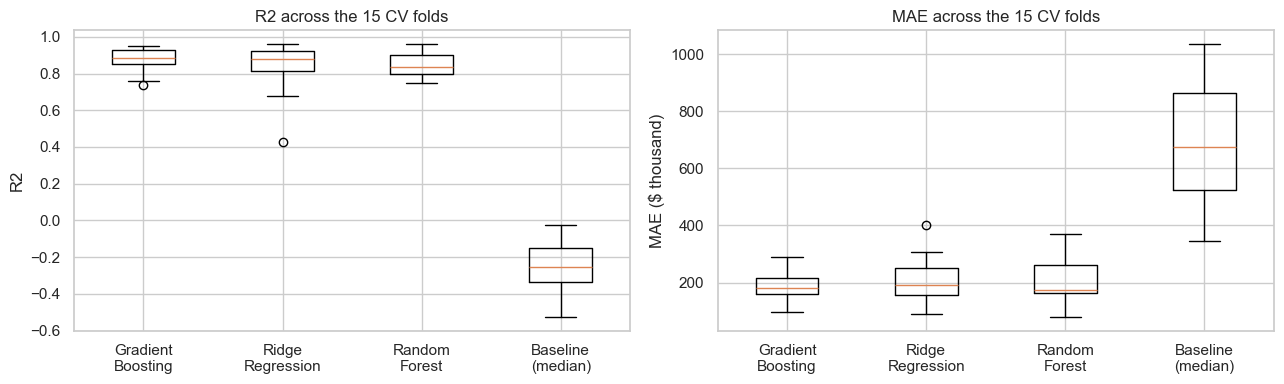

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = [m for m in res.index]
ax[0].boxplot([folds[m]["test_r2"] for m in order], labels=[m.replace(" ", "\n") for m in order]); ax[0].set(title="R2 across the 15 CV folds", ylabel="R2")
ax[1].boxplot([-folds[m]["test_mae"]/1e3 for m in order], labels=[m.replace(" ", "\n") for m in order]); ax[1].set(title="MAE across the 15 CV folds", ylabel="MAE ($ thousand)")
plt.tight_layout(); plt.show()

### 3.3 Underfitting, overfitting and model complexity
**What the next cells do.** Two diagnostics show how model complexity affects performance:
- **Learning curves** – training and cross-validated R² as the number of training rows grows. A big persistent gap means overfitting (or too little data); low scores for both mean underfitting.
- **Validation curves** – R² as one complexity setting is varied: Ridge `alpha` (more regularisation = simpler), Random Forest `max_depth` and Gradient Boosting `n_estimators` (larger/deeper = more complex).

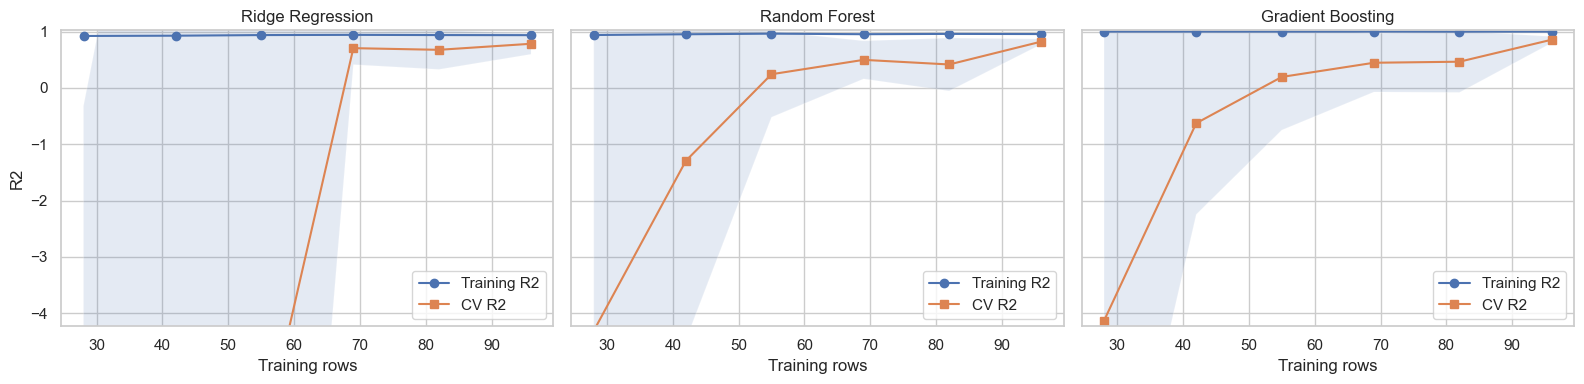

In [13]:
lc_fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, name in zip(axes, ["Ridge Regression", "Random Forest", "Gradient Boosting"]):
    est, scale = MODELS[name]; m = hf.build_model(clone(est), FEATURE_SETS["C_+text_flags"], REF_DATE, scale=scale)
    sizes, tr, te = learning_curve(m, X, y, train_sizes=np.linspace(0.3, 1.0, 6), cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
    ax.plot(sizes, tr.mean(1), "o-", label="Training R2"); ax.plot(sizes, te.mean(1), "s-", label="CV R2")
    ax.fill_between(sizes, te.mean(1)-te.std(1), te.mean(1)+te.std(1), alpha=.15)
    ax.set(title=name, xlabel="Training rows", ylim=(min(0, te.mean(1).min()-.1), 1.02)); ax.legend()
axes[0].set_ylabel("R2"); plt.tight_layout(); plt.show()

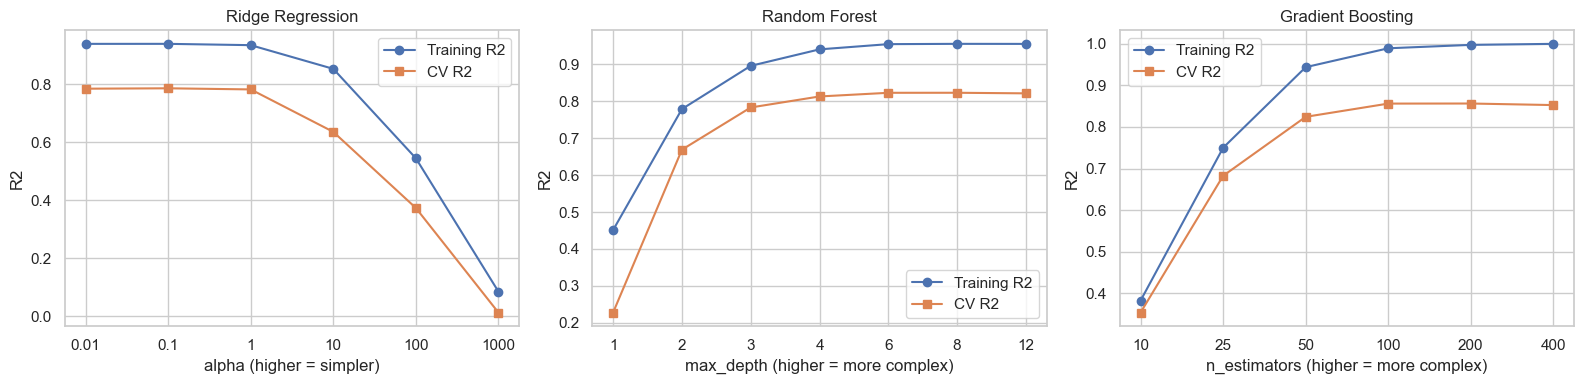

In [14]:
vc_fig, axes = plt.subplots(1, 3, figsize=(16, 4))
vc_specs = [("Ridge Regression", "regressor__model__alpha", [0.01, 0.1, 1, 10, 100, 1000], True, "alpha (higher = simpler)"),
            ("Random Forest", "regressor__model__max_depth", [1, 2, 3, 4, 6, 8, 12], False, "max_depth (higher = more complex)"),
            ("Gradient Boosting", "regressor__model__n_estimators", [10, 25, 50, 100, 200, 400], False, "n_estimators (higher = more complex)")]
for ax, (name, pname, grid, scale, label) in zip(axes, vc_specs):
    est, _ = MODELS[name]; m = hf.build_model(clone(est), FEATURE_SETS["C_+text_flags"], REF_DATE, scale=scale)
    tr, te = validation_curve(m, X, y, param_name=pname, param_range=grid, cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
    xs = range(len(grid)); ax.plot(xs, tr.mean(1), "o-", label="Training R2"); ax.plot(xs, te.mean(1), "s-", label="CV R2")
    ax.set_xticks(list(xs)); ax.set_xticklabels(grid); ax.set(title=name, xlabel=label, ylabel="R2"); ax.legend()
plt.tight_layout(); plt.show()

### 3.4 Did feature engineering help? Which variables matter?
**What the next cell does.** Repeats cross-validation for the best model (lowest CV RMSE above) on the three nested feature sets **A** (raw), **B** (+ engineered numeric) and **C** (+ text flags).
If a feature set does not lower the error, the extra features did not help on this data. The feature set with the lowest CV RMSE is used for the final model.

In [15]:
BEST_NAME = res.drop("Baseline (median)").index[0]
est, scale = MODELS[BEST_NAME]
abl = {}
for fset in FEATURE_SETS:
    r = evaluate(BEST_NAME, est, scale, fset)
    abl[fset] = {"CV RMSE ($)": -r["test_rmse"].mean(), "CV MAE ($)": -r["test_mae"].mean(), "CV R2": r["test_r2"].mean()}
abl = pd.DataFrame(abl).T; display(abl.round(3))
FINAL_FEATURE_SET = abl["CV RMSE ($)"].idxmin()
print(f"Best model: {BEST_NAME} | feature set with lowest CV RMSE: {FINAL_FEATURE_SET}")

,CV RMSE ($),CV MAE ($),CV R2
A_raw,"295,039.93","177,944.23",0.89
B_+engineered,"313,391.18","178,774.13",0.87
C_+text_flags,"311,719.42","187,294.40",0.88


Best model: Gradient Boosting | feature set with lowest CV RMSE: A_raw


**What the next cell does.** Measures **permutation importance** on held-out data: for each cross-validation fold the model is trained on the training part, then one *original* column at a time in the test part is randomly shuffled and the increase in prediction error is recorded.
A column whose shuffling hurts a lot is important. This is computed on unseen data, so it is not inflated by overfitting, and it is expressed in terms of the original columns (including the raw description text and suburb), which lets us compare the result with the expectation in Section 2.3.

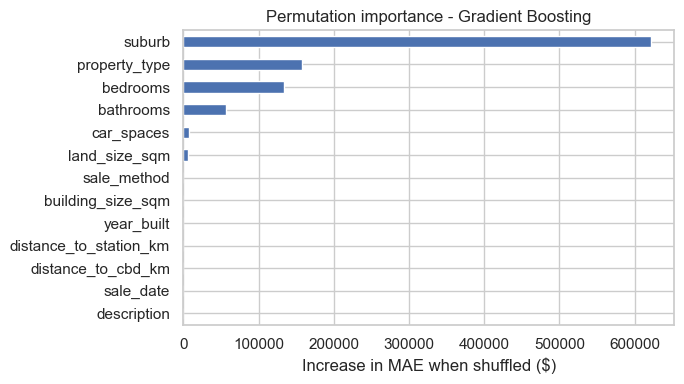

Top three variables by held-out permutation importance: ['suburb', 'property_type', 'bedrooms']


In [16]:
raw_cols = [c for c in hf.RAW_MODEL_COLUMNS if c in X.columns]
imps = []
for tr_idx, te_idx in KFold(5, shuffle=True, random_state=SEED).split(X):
    m = hf.build_model(clone(est), FEATURE_SETS[FINAL_FEATURE_SET], REF_DATE, scale=scale).fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pi = permutation_importance(m, X.iloc[te_idx][raw_cols], y.iloc[te_idx], scoring="neg_mean_absolute_error", n_repeats=10, random_state=SEED)
    imps.append(pi.importances_mean)
imp = pd.Series(np.mean(imps, axis=0), index=raw_cols).sort_values(ascending=False)
plt.figure(figsize=(7, 4)); imp[::-1].plot(kind="barh"); plt.xlabel("Increase in MAE when shuffled ($)"); plt.title(f"Permutation importance - {BEST_NAME}")
plt.tight_layout(); plt.show()
print("Top three variables by held-out permutation importance:", list(imp.index[:3]))

### 3.5 Were my expectations supported? Recommendation
**What the next cell does.** Compares the model I predicted would win with the model that actually had the lowest cross-validated RMSE and prints the recommendation evidence in one place
(accuracy, stability across folds, train/CV gap, and simplicity). The written justification goes in the report.

In [17]:
print(f"Predicted best model : {MY_PREDICTION}")
print(f"Actual best model    : {BEST_NAME}  (lowest CV RMSE, excluding the baseline)")
print("EXPECTATION SUPPORTED" if MY_PREDICTION == BEST_NAME else "EXPECTATION NOT SUPPORTED - explain why in the report")
best = res.loc[BEST_NAME]
print(f"\n{BEST_NAME}: MAE ${best['CV MAE ($)']:,.0f} | RMSE ${best['CV RMSE ($)']:,.0f} | MAPE {best['CV MAPE (%)']:.1f}% | R2 {best['CV R2']:.3f} (+/- {best['R2 std']:.3f}) | train-CV R2 gap {best['R2 gap (train - CV)']:.3f}")
print("Improvement over median baseline (MAE): %.0f%%" % (100 * (1 - best["CV MAE ($)"] / res.loc["Baseline (median)", "CV MAE ($)"])))

Predicted best model : Gradient Boosting
Actual best model    : Gradient Boosting  (lowest CV RMSE, excluding the baseline)
EXPECTATION SUPPORTED

Gradient Boosting: MAE $187,294 | RMSE $311,719 | MAPE 14.0% | R2 0.878 (+/- 0.062) | train-CV R2 gap 0.121
Improvement over median baseline (MAE): 73%


## Part 4 – Investigating prediction failures
**What the next cell does.** Produces an **out-of-fold prediction** for every property: each property is predicted by a model that never saw it during training (5-fold cross-validation), so the errors are honest estimates of how the model behaves on new properties.
It then plots actual against predicted prices and summarises the errors by suburb and property type.

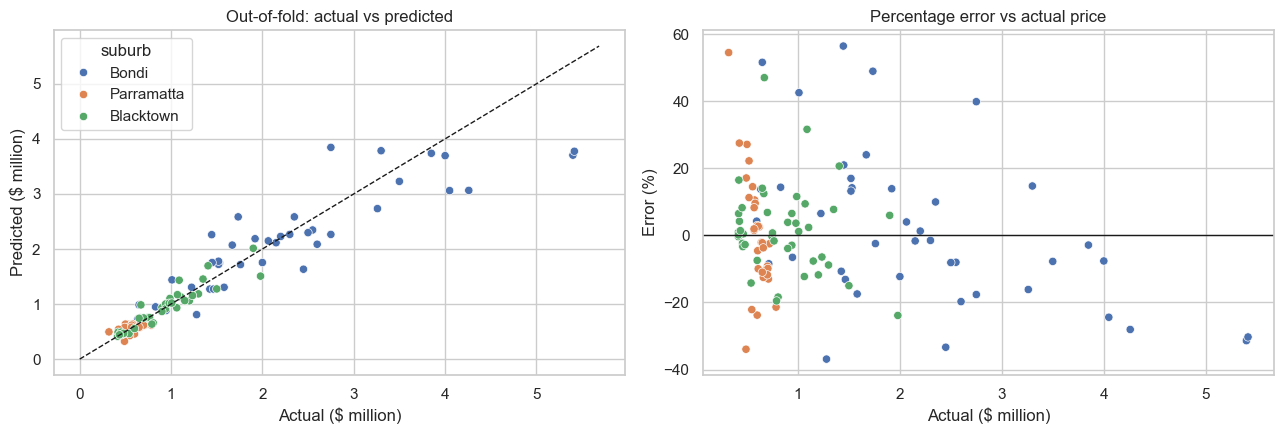

,n,MAE,MAPE,bias
suburb,,,,
Blacktown,45,"83,498.00",9.00,"3,086.00"
Bondi,42,"401,154.00",18.00,"-100,352.00"
Parramatta,33,"69,832.00",13.00,"-8,302.00"


,n,MAE,MAPE,bias
property_type,,,,
House,30,"371,599.00",15.00,"-164,986.00"
Other,1,"815,579.00",56.00,"815,579.00"
Townhouse,10,"59,764.00",8.00,"-7,284.00"
Unit,79,"131,002.00",13.00,"-1,811.00"


,n,MAE,MAPE,bias
price_band,,,,
Q1 lowest,30,"52,080.00",11.00,"24,083.00"
Q2,30,"71,782.00",11.00,"-3,005.00"
Q3,31,"172,736.00",14.00,"42,184.00"
Q4 highest,29,"477,230.00",16.00,"-216,896.00"


In [18]:
final_model = hf.build_model(clone(est), FEATURE_SETS[FINAL_FEATURE_SET], REF_DATE, scale=scale)
oof = cross_val_predict(final_model, X, y, cv=KFold(5, shuffle=True, random_state=SEED))
err = df.copy(); err["predicted"] = oof; err["error"] = err.predicted - err.sale_price
err["abs_error"] = err.error.abs(); err["pct_error"] = 100 * err.error / err.sale_price

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=err, x=err.sale_price/1e6, y=err.predicted/1e6, hue="suburb", ax=ax[0])
lim = [0, max(err.sale_price.max(), err.predicted.max())/1e6*1.05]; ax[0].plot(lim, lim, "k--", lw=1); ax[0].set(title="Out-of-fold: actual vs predicted", xlabel="Actual ($ million)", ylabel="Predicted ($ million)")
sns.scatterplot(data=err, x=err.sale_price/1e6, y=err.pct_error, hue="suburb", ax=ax[1], legend=False); ax[1].axhline(0, color="k", lw=1); ax[1].set(title="Percentage error vs actual price", xlabel="Actual ($ million)", ylabel="Error (%)")
plt.tight_layout(); plt.show()

by = lambda col: err.groupby(col).agg(n=("error", "size"), MAE=("abs_error", "mean"), MAPE=("pct_error", lambda s: s.abs().mean()), bias=("error", "mean")).round(0)
display(by("suburb"))
if "property_type" in err: display(by("property_type"))
err["price_band"] = pd.qcut(err.sale_price, 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"]); display(by("price_band"))

**What the next cell does.** Lists the **five properties with the largest absolute errors** and prints a case file for each: its features, actual and predicted price, the size of the error, the agent's description and the listing link (if you recorded it).
Use these case files, together with the original listings (photos, floor plan, street position, sale method), to investigate *why* the model failed for each one in the report.

In [19]:
top5 = err.sort_values("abs_error", ascending=False).head(5)
cols = [c for c in ["address","suburb","property_type","bedrooms","bathrooms","car_spaces","land_size_sqm","sale_method","sale_date","sale_price","predicted","error","pct_error"] if c in top5]
display(top5[cols].round(1))
for rank, (i, r) in enumerate(top5.iterrows(), 1):
    print(f"\n=== Case {rank}: {r.get('address', 'row ' + str(i))} ({r.suburb}) ===")
    print(f"Actual ${r.sale_price:,.0f} | Predicted ${r.predicted:,.0f} | Error ${r.error:,.0f} ({r.pct_error:+.1f}%)")
    print({c: r[c] for c in ["property_type","bedrooms","bathrooms","car_spaces","land_size_sqm","building_size_sqm","year_built","sale_method","sale_date"] if c in r.index and pd.notna(r[c])})
    if "description" in r.index and isinstance(r.description, str): print("Agent description:", r.description[:400])
    if "listing_url" in r.index and isinstance(r.listing_url, str): print("Listing:", r.listing_url)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,sale_method,sale_date,sale_price,predicted,error,pct_error
11,1 Miller Street,Bondi,House,5.00,4.00,3.00,307.00,NaN,2026-08-12,"5,400,000.00","3,704,952.60","-1,695,047.40",-31.40
26,14 Anglesea Street,Bondi,House,6.00,4.00,1.00,415.00,NaN,2026-05-19,"5,416,000.00","3,775,374.90","-1,640,625.10",-30.30
21,38 Philip Street,Bondi,House,3.00,2.00,0.00,NaN,NaN,2026-06-02,"4,260,000.00","3,064,771.80","-1,195,228.20",-28.10
9,8B Castlefield Street,Bondi,House,3.00,2.00,1.00,NaN,NaN,2026-08-25,"2,750,000.00","3,846,196.00","1,096,196.00",39.90
27,76 Edward Street,Bondi,House,3.00,2.00,1.00,NaN,NaN,2026-05-14,"4,050,000.00","3,061,335.50","-988,664.50",-24.40



=== Case 1: 1 Miller Street (Bondi) ===
Actual $5,400,000 | Predicted $3,704,953 | Error $-1,695,047 (-31.4%)
{'property_type': 'House', 'bedrooms': 5.0, 'bathrooms': 4.0, 'car_spaces': 3.0, 'land_size_sqm': 307.0, 'sale_date': Timestamp('2026-08-12 00:00:00')}
Agent description: Large three-level family home on 307 sqm with five bedrooms, self-contained living option, north-facing backyard and three off-street spaces.
Listing: https://www.realestate.com.au/sold/property-house-nsw-bondi-151863008

=== Case 2: 14 Anglesea Street (Bondi) ===
Actual $5,416,000 | Predicted $3,775,375 | Error $-1,640,625 (-30.3%)
{'property_type': 'House', 'bedrooms': 6.0, 'bathrooms': 4.0, 'car_spaces': 1.0, 'land_size_sqm': 415.0, 'sale_date': Timestamp('2026-05-19 00:00:00')}
Agent description: Substantial six-bedroom family home on approximately 415 sqm with landscaped gardens, outdoor entertaining and a large kitchen.
Listing: https://www.realestate.com.au/sold/property-house-nsw-bondi-150991856

=== 

In [20]:
# Context for the five largest errors: how do similar properties (same suburb, type and bedrooms) compare?
rows = []
for i, r in top5.iterrows():
    peers = err[(err.suburb == r.suburb) & (err.property_type == r.property_type) & (err.bedrooms == r.bedrooms) & (err.index != i)]
    rows.append({"address": r.get("address", i), "actual": r.sale_price, "predicted": r.predicted, "error_%": r.pct_error,
                 "similar_n": len(peers), "similar_median": peers.sale_price.median(),
                 "similar_min": peers.sale_price.min(), "similar_max": peers.sale_price.max(),
                 "land_size_listed": bool(pd.notna(r.get("land_size_sqm"))),
                 "description_used_by_model": "txt_word_count" in FEATURE_SETS[FINAL_FEATURE_SET]["num"]})
display(pd.DataFrame(rows).round(0))
print("Feature set used for the final model:", FINAL_FEATURE_SET)

,address,actual,predicted,error_%,similar_n,similar_median,similar_min,similar_max,land_size_listed,description_used_by_model
0,1 Miller Street,"5,400,000.00","3,704,953.00",-31.00,0,NaN,NaN,NaN,True,False
1,14 Anglesea Street,"5,416,000.00","3,775,375.00",-30.00,0,NaN,NaN,NaN,True,False
2,38 Philip Street,"4,260,000.00","3,064,772.00",-28.00,5,"3,300,000.00","2,750,000.00","4,050,000.00",False,False
3,8B Castlefield Street,"2,750,000.00","3,846,196.00",40.00,5,"3,500,000.00","3,260,000.00","4,260,000.00",False,False
4,76 Edward Street,"4,050,000.00","3,061,335.00",-24.00,5,"3,300,000.00","2,750,000.00","4,260,000.00",False,False


Feature set used for the final model: A_raw


### Interpretation of the five largest prediction errors

All five largest errors are **Bondi houses** (errors of $0.99M–$1.70M, or 24–40% of the price). The final model used only raw features (bedrooms, bathrooms, car spaces, land size, suburb, property type), so it could not see the listing description, exact location or condition, and land size is blank for three of the five.

**1. 1 Miller Street (5 bed / 4 bath / 3 car, 307 sqm).** Sold $5.40M; predicted $3.70M (31% too low). **2. 14 Anglesea Street (6 / 4 / 1, 415 sqm).** Sold $5.416M; predicted $3.78M (30% too low). These are the two most expensive sales in the dataset and the only Bondi houses with five or more bedrooms. With no comparable sales, the model had to extrapolate, and tree ensembles cannot predict beyond the prices they have seen, so both were pulled towards about $3.7M. Their listings describe self-contained living and large grounds, which the model saw only as bedroom counts.

**3. 38 Philip Street (3 / 2 / 0, land not listed).** Sold $4.26M; predicted $3.06M (28% too low). It is the most expensive 3-bedroom house (comparables $2.75M–$4.05M, median $3.3M). The description stresses architect design, double-height living and a north-facing courtyard, a design and aspect premium that raw features cannot express.

**4. 8B Castlefield Street (3 / 2 / 1, land not listed).** Sold $2.75M; predicted $3.85M (40% too high). It is the cheapest Bondi house in the data (comparables $3.26M–$4.26M). The "8B" address may indicate a rear or subdivided lot and the listing places it near Bondi Road, but block size is unknown. These are hypotheses to check against the listing.

**5. 76 Edward Street (3 / 2 / 1, land not listed).** Sold $4.05M; predicted $3.06M (24% too low). The description mentions ocean and district outlooks, a north-facing aspect and upgraded interiors: a views premium the model cannot see.

**What the cases show.** Missing information, not random noise, is the most likely cause (land size, views, design and condition, street position). The model pulls unusual properties toward the typical price of their group, so the dearest and cheapest houses are predicted worst. Bondi houses are few (10), expensive and varied, so a $1M error is about 25–40% of the price. Predictions should be treated cautiously for premium or unique houses and for suburb–type combinations not seen in training.

## Part 5 (support) – Train the final model and save it for the web app
**What the next cell does.** Trains the chosen model on **all** the data and saves it (`model.joblib`) with a small metadata file (`model_metadata.json`) that the app reads. The metadata contains:
the dropdown options (suburbs, property types, sale methods), the ranges seen in training (so the app can warn when an input is outside them), the cross-validated error, and an **approximate prediction range** taken from the 10th and 90th percentiles of actual/predicted price ratios in the out-of-fold predictions.
The last lines reload the saved model and predict one example to confirm the saved file works.

In [21]:
final_model.fit(X, y)
joblib.dump(final_model, "model.joblib")

ratio = (err.sale_price / err.predicted)
fs = FEATURE_SETS[FINAL_FEATURE_SET]
used_raw = sorted({c for c in fs["num"] + fs["cat"] if c in hf.RAW_MODEL_COLUMNS} | ({"description"} if fs["flags"] else set()) | {"sale_date"})
meta = {
    "model_name": BEST_NAME, "feature_set": FINAL_FEATURE_SET, "n_training_rows": int(len(df)),
    "ref_date": str(REF_DATE.date()), "latest_sale_date": str(df.sale_date.max().date()),
    "inputs_used": used_raw,
    "suburbs": sorted(df.suburb.dropna().unique().tolist()),
    "property_types": sorted(df.property_type.dropna().unique().tolist()) if "property_type" in df else [],
    "sale_methods": sorted(df.sale_method.dropna().unique().tolist()) if "sale_method" in df else [],
    "ranges": {c: [float(df[c].min()), float(df[c].max())] for c in hf.RAW_NUMERIC if c in df and df[c].notna().any()},
    "price_range": [float(df.sale_price.min()), float(df.sale_price.max())],
    "cv_mae": float(best["CV MAE ($)"]), "cv_rmse": float(best["CV RMSE ($)"]), "cv_mape_pct": float(best["CV MAPE (%)"]), "cv_r2": float(best["CV R2"]),
    "ratio_low": float(ratio.quantile(0.10)), "ratio_high": float(ratio.quantile(0.90)),
    "median_price_by_suburb": df.groupby("suburb").sale_price.median().round(0).to_dict(),
}
with open("model_metadata.json", "w") as f: json.dump(meta, f, indent=2)

reloaded = joblib.load("model.joblib")
example = hf.make_input_frame({"suburb": meta["suburbs"][0], "property_type": (meta["property_types"] or ["House"])[0],
                               "bedrooms": 3, "bathrooms": 2, "car_spaces": 1, "sale_date": meta["latest_sale_date"],
                               "description": "Renovated home with a pool and city views"})
p, lo, hi = hf.predict_with_range(reloaded, example, meta["ratio_low"], meta["ratio_high"])
print(f"Saved model.joblib and model_metadata.json. Example prediction: ${p[0]:,.0f} (range ${lo[0]:,.0f} - ${hi[0]:,.0f})")

Saved model.joblib and model_metadata.json. Example prediction: $792,531 (range $654,403 - $985,196)


## Reproducibility notes
- Random seed 42 is used for all splits and models, so results are repeatable on the same library versions (`requirements.txt`).
- To launch the web app after running this notebook: `streamlit run app.py` (see `README.md`).
- Interpretation, case-by-case failure analysis and reflection are written in the PDF report.